In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import config
from src import *

# **1. Download data**

In [2]:
tickers = config.tickers
data = DataLoader(tickers)
data.download_data(start_date = config.start_date, end_date = config.end_date)

[*********************100%***********************]  100 of 100 completed


Price        Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2010-01-04    6.418383         NaN   18.321978   37.090000   25.670000   
2010-01-05    6.429481         NaN   18.173944   37.700001   25.280001   
2010-01-06    6.327210         NaN   18.274881   37.619999   25.340000   
2010-01-07    6.315513         NaN   18.426268   36.889999   25.480000   
2010-01-08    6.357500         NaN   18.520472   36.689999   26.260000   
...                ...         ...         ...         ...         ...   
2025-10-06  256.441406  226.718307  132.476868  350.140015  323.429993   
2025-10-07  256.231628  229.318481  131.763657  348.309998  314.190002   
2025-10-08  257.810089  227.752457  133.001862  348.769989  311.410004   
2025-10-09  253.793961  227.210754  132.050919  347.470001  310.320007   
2025-10-10  245.032471  227.023605  131.317917  337.510010  303.500000   

Price                                                                    ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2010-01-04    9.700000   39.311676    6.695000   51.433228    32.425720  ...   
2010-01-05    9.710000   38.971138    6.734500   51.006458    32.678329  ...   
2010-01-06    9.570000   38.678295    6.612500   50.585880    32.977684  ...   
2010-01-07    9.470000   38.324104    6.500000   50.295200    32.060871  ...   
2010-01-08    9.430000   38.664669    6.676000   50.616810    31.293736  ...   
...                ...         ...         ...         ...          ...  ...   
2025-10-06  203.710007  292.037079  220.899994  268.986603  1041.452271  ...   
2025-10-07  211.509995  293.447021  221.779999  268.927032  1000.524902  ...   
2025-10-08  235.559998  292.533539  225.220001  266.633759   986.060547  ...   
2025-10-09  232.889999  293.337799  227.740005  260.806305   978.803406  ...   
2025-10-10  214.899994  288.075348  216.369995  255.217087   934.531982  ...   

Price           Volume                                                   \
Ticker            UBER       UL       UNH       UPS         V       WFC   
Date                                                                      
2010-01-04         NaN   709690  12199500   3897200  20180000  39335700   
2010-01-05         NaN   825396  11180700   5966300  25833600  55416000   
2010-01-06         NaN  1608701   9761100   5770200  16254000  33237000   
2010-01-07         NaN  1212386  11789800   5747000  27841200  61649000   
2010-01-08         NaN   676390   7228700  13779300  11907200  35508700   
...                ...      ...       ...       ...       ...       ...   
2025-10-06  22760900.0  1801397   7181700   6987000   4735600  12837700   
2025-10-07  12583600.0  1941701   7236200   4726800   5044600  10371300   
2025-10-08  10071200.0  1617314   9438300   4896000   3927500  11277400   
2025-10-09  13435700.0  2237760   8759800   5784700   4434800   8432200   
2025-10-10  17021100.0  4715990  13141900   8506000   6296200  16004300   

Price                                               
Ticker           WMT       XOM        XYZ      YUM  
Date                                                
2010-01-04  62259300  27809100        NaN  2962274  
2010-01-05  46945200  30174700        NaN  3298757  
2010-01-06  37551600  35044700        NaN  4178981  
2010-01-07  31988100  27192100        NaN  2452472  
2010-01-08  34089600  24891800        NaN  3772392  
...              ...       ...        ...      ...  
2025-10-06  13303600  12036800  5324100.0  1395000  
2025-10-07  15538900  11945000  5428000.0  1657100  
2025-10-08  13584100  12301000  6024900.0  1150600  
2025-10-09  19508000  10976200  4193600.0  1371000  
2025-10-10  18519400  13811600  8802300.0  2055300  

[3968 rows x 600 columns]

In [3]:
data.save_df(filename='price_volume_data.csv')

In [4]:
sp500_price = yf.download(tickers='^GSPC', start=config.start_date, end=config.end_date, auto_adjust=False)['Adj Close']   # ^GSPC là mã S&P 500
sp500_price.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2010-01-04,1132.989990
2010-01-05,1136.520020
2010-01-06,1137.140015
2010-01-07,1141.689941
2010-01-08,1144.979980


# **2. Data Preparation and Oulier Handling**

In [5]:
from src.data.data_processor import DataProcessor

In [6]:
data = pd.read_csv("price_volume_data.csv", header=[0, 1], index_col=0, parse_dates=True)
data.head()

Price      Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418383  NaN  18.321978  37.090000  25.670000  9.70  39.311676   
2010-01-05  6.429481  NaN  18.173944  37.700001  25.280001  9.71  38.971138   
2010-01-06  6.327210  NaN  18.274881  37.619999  25.340000  9.57  38.678295   
2010-01-07  6.315513  NaN  18.426268  36.889999  25.480000  9.47  38.324104   
2010-01-08  6.357500  NaN  18.520472  36.689999  26.260000  9.43  38.664669   

Price                                     ... Volume                     \
Ticker        AMZN        APD       ASML  ...   UBER       UL       UNH   
Date                                      ...                             
2010-01-04  6.6950  51.433228  32.425720  ...    NaN   709690  12199500   
2010-01-05  6.7345  51.006458  32.678329  ...    NaN   825396  11180700   
2010-01-06  6.6125  50.585880  32.977684  ...    NaN  1608701   9761100   
2010-01-07  6.5000  50.295200  32.060871  ...    NaN  1212386  11789800   
2010-01-08  6.6760  50.616810  31.293736  ...    NaN   676390   7228700   

Price                                                                      
Ticker           UPS         V       WFC       WMT       XOM XYZ      YUM  
Date                                                                       
2010-01-04   3897200  20180000  39335700  62259300  27809100 NaN  2962274  
2010-01-05   5966300  25833600  55416000  46945200  30174700 NaN  3298757  
2010-01-06   5770200  16254000  33237000  37551600  35044700 NaN  4178981  
2010-01-07   5747000  27841200  61649000  31988100  27192100 NaN  2452472  
2010-01-08  13779300  11907200  35508700  34089600  24891800 NaN  3772392  

[5 rows x 600 columns]

In [7]:
processor = DataProcessor("price_volume_data.csv")

df = processor.process()
df.head()

Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418383  NaN  18.321978  37.090000  25.670000  9.70  39.311676   
2010-01-05  6.429481  NaN  18.173944  37.700001  25.280001  9.71  38.971138   
2010-01-06  6.327210  NaN  18.274881  37.619999  25.340000  9.57  38.678295   
2010-01-07  6.315513  NaN  18.426268  36.889999  25.480000  9.47  38.324104   
2010-01-08  6.357500  NaN  18.520472  36.689999  26.260000  9.43  38.664669   

                                          ... Log Return                      \
Ticker        AMZN        APD       ASML  ...       UBER        UL       UNH   
Date                                      ...                                  
2010-01-04  6.6950  51.433228  32.425720  ...        NaN       NaN       NaN   
2010-01-05  6.7345  51.006458  32.678329  ...        NaN -0.022034 -0.001587   
2010-01-06  6.6125  50.585880  32.977684  ...        NaN -0.005425  0.009799   
2010-01-07  6.5000  50.295200  32.060871  ...        NaN -0.007065  0.037659   
2010-01-08  6.6760  50.616810  31.293736  ...        NaN  0.004823 -0.009435   

                                                                            
Ticker           UPS         V       WFC       WMT       XOM XYZ       YUM  
Date                                                                        
2010-01-04       NaN       NaN       NaN       NaN       NaN NaN       NaN  
2010-01-05  0.001718 -0.011525  0.027082 -0.010008  0.003897 NaN -0.003426  
2010-01-06 -0.007406 -0.013519  0.001424 -0.002238  0.008606 NaN -0.007174  
2010-01-07 -0.007634  0.009264  0.035643  0.000560 -0.003147 NaN -0.000289  
2010-01-08  0.037015  0.002762 -0.009312 -0.005050 -0.004020 NaN  0.000289  

[5 rows x 700 columns]

In [8]:
c = Calculate("cleaned_price_volume_data.csv")
c.add_indicators()

c.df.to_csv("price_volume_indicators_data.csv")

# c.calculate_position_size()

print(set(c.df.columns.get_level_values(0)))
c.df.tail()

{'High', 'Open', 'Adj Close', 'Low', 'SMA_200', 'SMA_50', 'Volatility', 'Log Return', 'Volume', 'Close'}


Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2025-10-06  256.441406  226.718307  132.476868  350.140015  323.429993   
2025-10-07  256.231628  229.318481  131.763672  348.309998  314.190002   
2025-10-08  257.810089  227.752457  133.001862  348.769989  311.410004   
2025-10-09  253.793961  227.210754  132.050919  347.470001  310.320007   
2025-10-10  245.032471  227.023605  131.317917  337.510010  303.500000   

                                                                         ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2025-10-06  203.710007  292.037079  220.899994  268.986603  1041.452271  ...   
2025-10-07  211.509995  293.447021  221.779999  268.927032  1000.524902  ...   
2025-10-08  235.559998  292.533539  225.220001  266.633759   986.060547  ...   
2025-10-09  232.889999  293.337799  227.740005  260.806305   978.803406  ...   
2025-10-10  214.899994  288.075348  216.369995  255.217087   934.531982  ...   

           Volatility                                                    \
Ticker           UBER        UL       UNH       UPS         V       WFC   
Date                                                                      
2025-10-06   0.340511  0.114900  0.251534  0.158889  0.187511  0.184932   
2025-10-07   0.332844  0.116157  0.250673  0.158124  0.189085  0.185560   
2025-10-08   0.334374  0.110914  0.207018  0.158309  0.189213  0.182772   
2025-10-09   0.352972  0.114522  0.208329  0.162004  0.184012  0.182012   
2025-10-10   0.365892  0.142903  0.240623  0.188054  0.179868  0.201537   

                                                    
Ticker           WMT       XOM       XYZ       YUM  
Date                                                
2025-10-06  0.145096  0.191584  0.329469  0.199246  
2025-10-07  0.133365  0.191213  0.331345  0.189073  
2025-10-08  0.133994  0.190642  0.340763  0.182260  
2025-10-09  0.122750  0.186059  0.327480  0.199029  
2025-10-10  0.094926  0.197964  0.437527  0.182778  

[5 rows x 1000 columns]

## **3. EDA**

In [9]:
%load_ext autoreload
%autoreload 2

In [10]:
from src.plot import EDAPlots

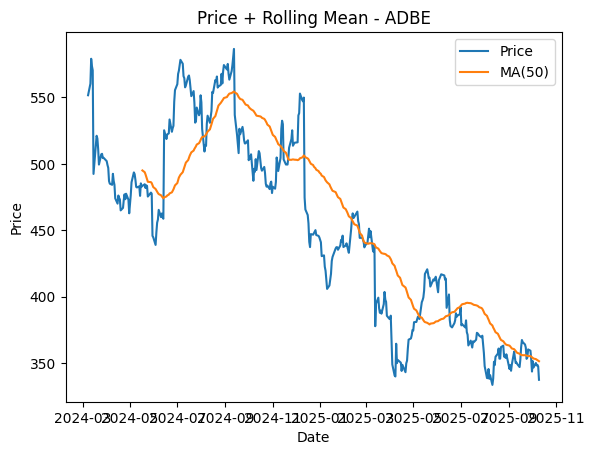

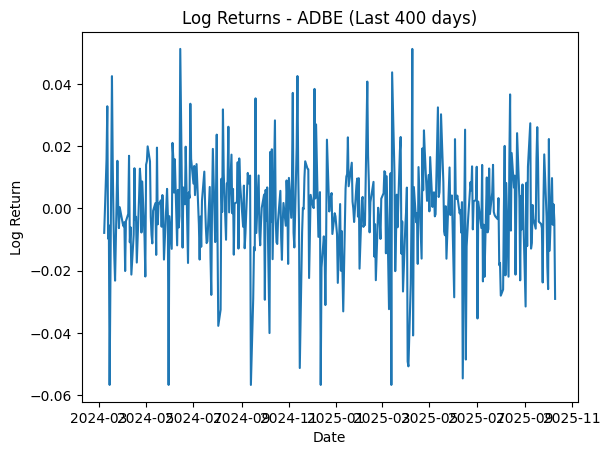

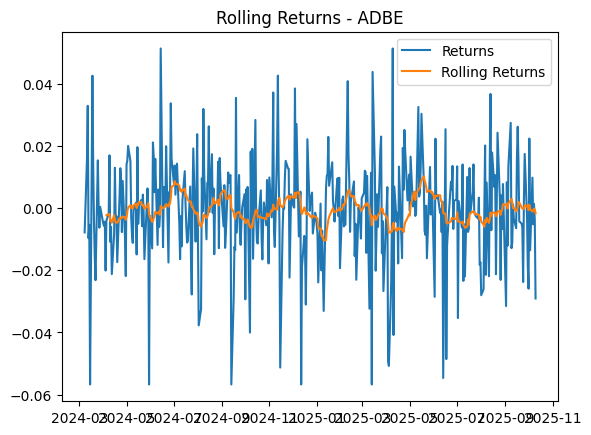

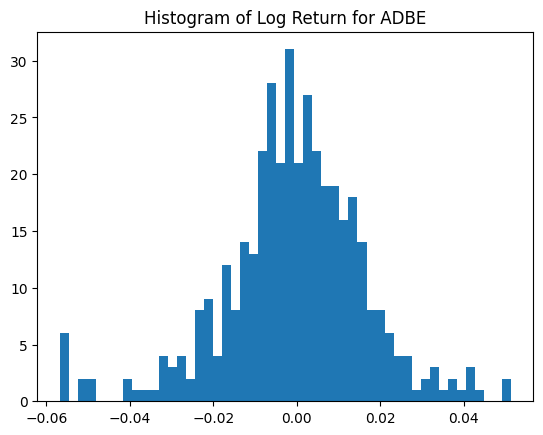

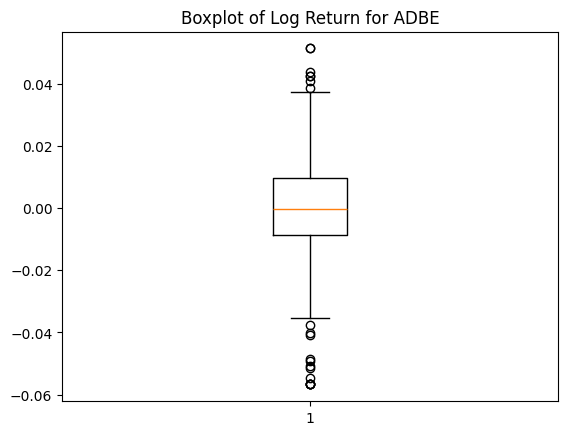

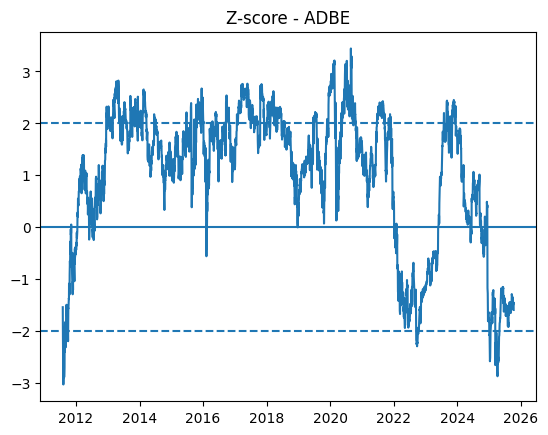

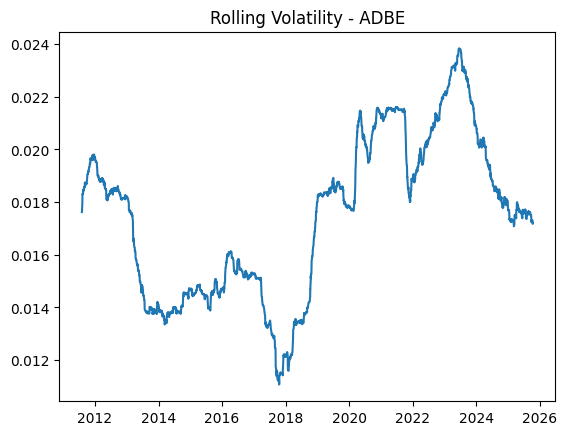

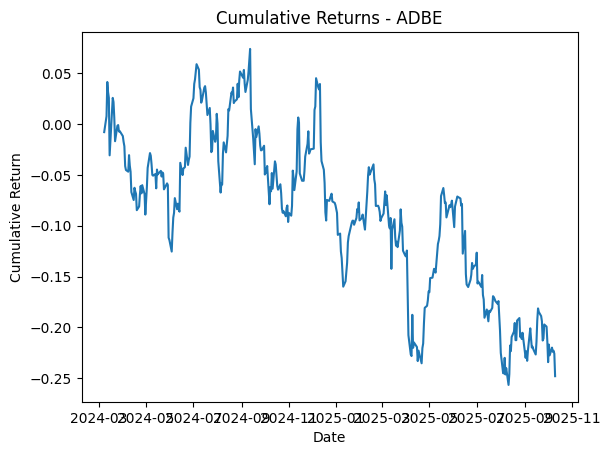

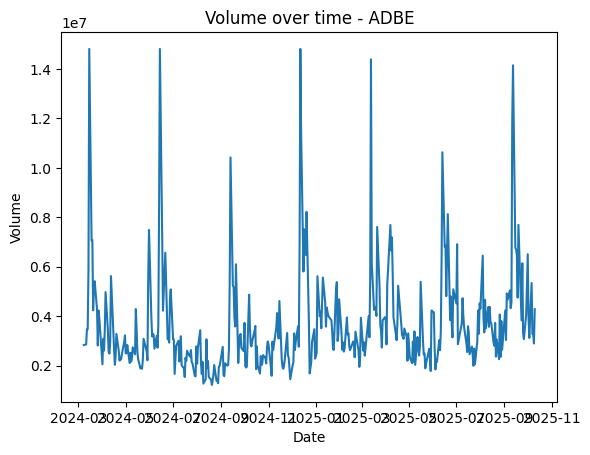

In [11]:
# Xet ticker ADBE

eda = EDAPlots()
ticker = "ADBE"
days = 400

eda.plot_price_with_rolling_mean(df, ticker, 50, days)
eda.plot_returns(df, ticker, days)
eda.plot_rolling_returns(df, ticker, 20, days)
eda.draw_histogram(df, ticker, "Log Return", days)
eda.draw_boxplot(df, ticker, "Log Return", days)
eda.plot_zscore(df, ticker, days)
eda.plot_rolling_volatility(df, ticker, days)
eda.plot_cumulative_returns(df, ticker, days)
eda.plot_volume(df, ticker, days)


# **3. Trading Strategy**

In [12]:
df = pd.read_csv("price_volume_indicators_data.csv", header=[0, 1], index_col=0, parse_dates=True)
print(set(df.columns.get_level_values(0)))

{'High', 'Open', 'Adj Close', 'Low', 'SMA_200', 'SMA_50', 'Volatility', 'Log Return', 'Volume', 'Close'}


In [13]:
df.head()

Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418382  NaN  18.321968  37.090000  25.670000  9.70  39.311680   
2010-01-05  6.429481  NaN  18.173939  37.700001  25.280001  9.71  38.971142   
2010-01-06  6.327210  NaN  18.274878  37.619999  25.340000  9.57  38.678284   
2010-01-07  6.315514  NaN  18.426270  36.889999  25.480000  9.47  38.324120   
2010-01-08  6.357502  NaN  18.520462  36.689999  26.260000  9.43  38.664650   

                                          ... Volatility                      \
Ticker        AMZN        APD       ASML  ...       UBER  UL UNH UPS   V WFC   
Date                                      ...                                  
2010-01-04  6.6950  51.433224  32.425720  ...        NaN NaN NaN NaN NaN NaN   
2010-01-05  6.7345  51.006470  32.678322  ...        NaN NaN NaN NaN NaN NaN   
2010-01-06  6.6125  50.585892  32.977680  ...        NaN NaN NaN NaN NaN NaN   
2010-01-07  6.5000  50.295208  32.060863  ...        NaN NaN NaN NaN NaN NaN   
2010-01-08  6.6760  50.616810  31.293734  ...        NaN NaN NaN NaN NaN NaN   

                            
Ticker     WMT XOM XYZ YUM  
Date                        
2010-01-04 NaN NaN NaN NaN  
2010-01-05 NaN NaN NaN NaN  
2010-01-06 NaN NaN NaN NaN  
2010-01-07 NaN NaN NaN NaN  
2010-01-08 NaN NaN NaN NaN  

[5 rows x 1000 columns]

## **3.1. Momentum Strategy**

In [14]:
momentum = MomentumStrategy(df)
momentum_signals = momentum.generate_signals()
momentum_signals.tail()

Signal                                               ...            \
Ticker       AAPL ABBV  ABT ADBE ADSK  AMD AMGN AMZN  APD ASML  ... UBER   UL   
Date                                                            ...             
2025-10-06    1.0  1.0  1.0 -1.0  1.0  0.0  1.0 -1.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-07    1.0  1.0  1.0 -1.0  1.0  1.0  1.0 -1.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-08    1.0  1.0  1.0 -1.0  1.0  1.0  1.0 -1.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-09    1.0  1.0  1.0 -1.0  1.0  1.0  1.0  0.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-10    1.0  1.0  1.0 -1.0  0.0  1.0  1.0  0.0 -1.0  1.0  ...  0.0 -1.0   

                                                    
Ticker      UNH  UPS    V  WFC  WMT  XOM  XYZ  YUM  
Date                                                
2025-10-06  1.0  1.0  1.0  0.0  1.0  1.0  1.0  1.0  
2025-10-07  1.0  1.0  1.0  0.0  1.0  1.0  1.0  0.0  
2025-10-08  1.0  1.0  1.0  0.0  1.0  1.0  1.0  0.0  
2025-10-09  1.0  0.0  1.0  0.0  1.0  1.0  1.0 -1.0  
2025-10-10  1.0 -1.0  1.0 -1.0  1.0  0.0  0.0 -1.0  

[5 rows x 100 columns]

In [15]:
viz = Visualizer()

### **Backtest**

In [16]:
tester = Backtester(df, initial_capital=config.initial_capital, transaction_cost=config.transaction_cost)
train_df, val_df, test_df = tester.split_data(train_end=config.train_end, val_end=config.val_end)

In [17]:
# Train set
eq_train, m_train = tester.run_and_evaluate(train_df, MomentumStrategy, "Momentum (Train)")
display(m_train)

,Total Return,Sharpe Ratio,Max Drawdown
Momentum (Train),-25.87%,-0.19,-39.26%


In [18]:
# Validation set - Hyperparameter Tuning
momentum_params = config.momentum_params

momentum_results = tester.optimize_grid_search(val_df, MomentumStrategy, momentum_params)

best = momentum_results.iloc[0]
display(best.to_frame().T)
# viz.plot_tuning_heatmap(tuning_res, metric='Sharpe Ratio')

,Total Return,Sharpe Ratio,Max Drawdown,threshold,window
12,-6.03%,-0.07,-18.04%,0.04,20


In [19]:
best_w = int(best['window'])
best_t = best['threshold']
print(f"BEST PARAMS: Window={best_w}, Threshold={best_t}")

# Chạy Backtest trên tập Test với tham số tối ưu
equity_test, metrics_test = tester.run_and_evaluate(
    test_df, MomentumStrategy, 
    label=f"Momentum - Test (W{best_w}-T{best_t})", 
    window=best_w, threshold=best_t
)

display(metrics_test)

BEST PARAMS: Window=20, Threshold=0.04


,Total Return,Sharpe Ratio,Max Drawdown
Momentum - Test (W20-T0.04),-9.79%,-0.53,-16.20%


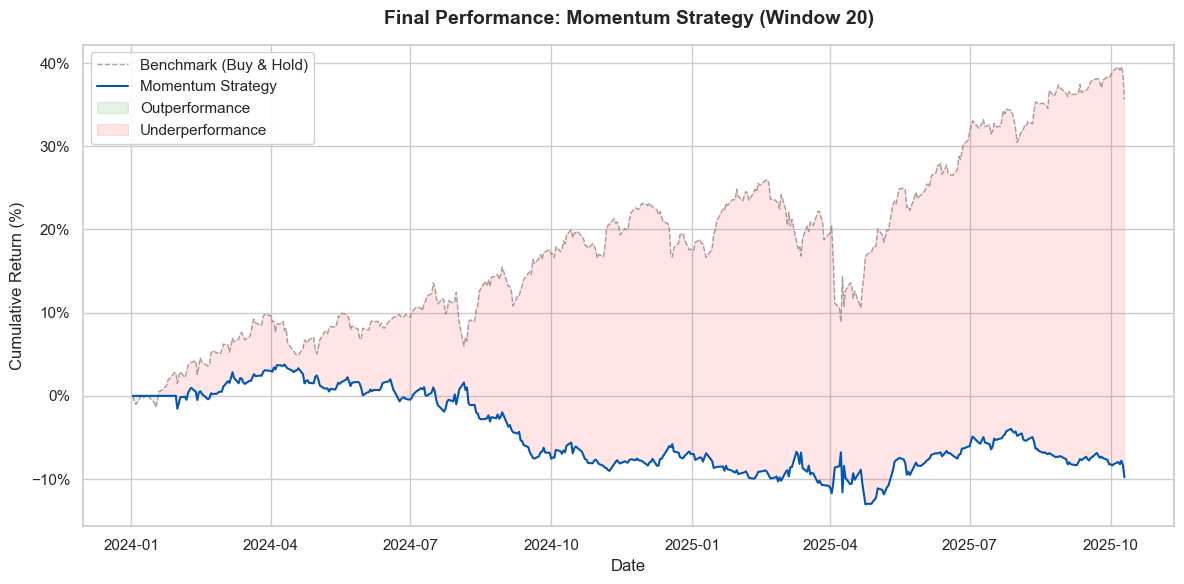

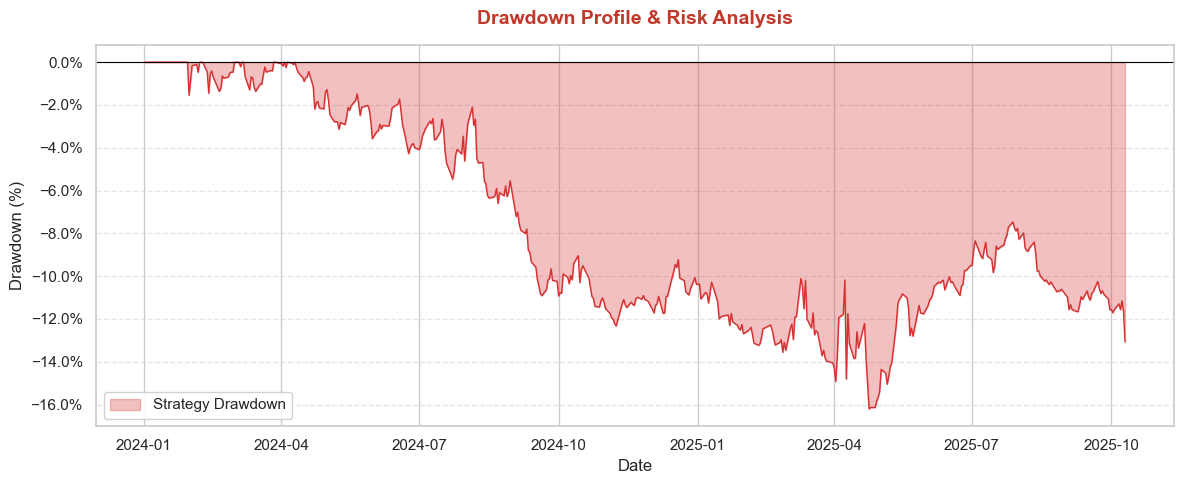

CẢNH BÁO: Phát hiện dữ liệu đầu vào là Portfolio Value ($). Đang chuyển đổi sang Returns (%)...


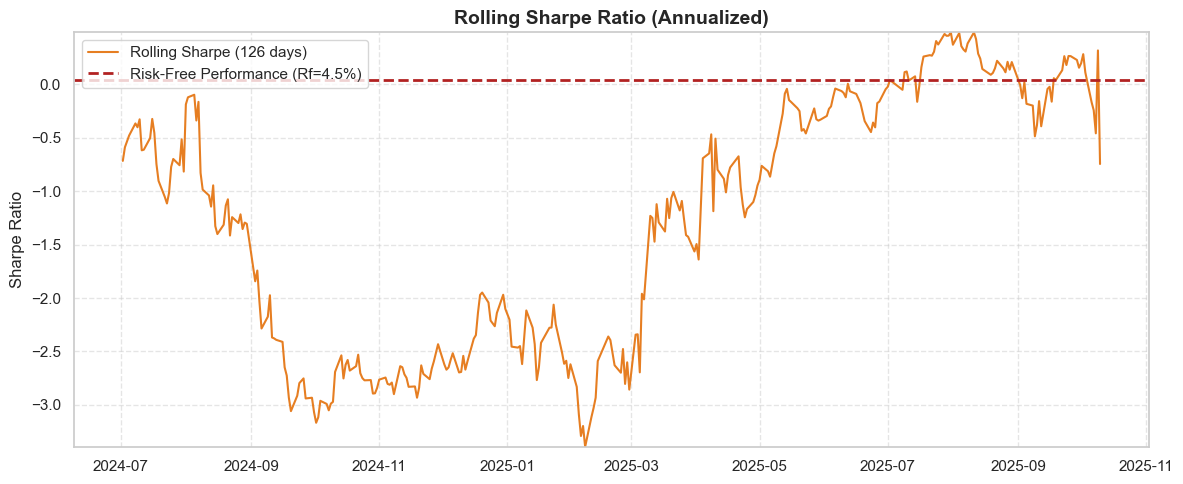

In [20]:
# Tạo Benchmark (Giả sử mua đều thị trường và nắm giữ)
simple_rets = np.exp(test_df['Log Return']) - 1
bench_simple_ret = simple_rets.mean(axis=1)
bench_equity = (1 + bench_simple_ret).cumprod() * tester.initial_capital

# Vẽ biểu đồ so sánh
viz.plot_strategy_vs_benchmark(
    equity_test, 
    bench_equity, 
    title=f"Final Performance: Momentum Strategy (Window {best_w})"
)

# (Tuỳ chọn) Vẽ biểu đồ rủi ro (Underwater)
viz.plot_underwater(equity_test)

viz.plot_rolling_sharpe(equity_test, risk_free_rate=config.risk_free_rate)

**Nhận xét:**
- Hiệu suất: Chiến lược Momentum thất bại hoàn toàn khi lỗ khoảng 10%, trong khi thị trường chung lãi tới 40%.
- Rủi ro sụt giảm (Drawdown): Trạng thái sụt giảm kéo dài với Maximum Drawdown ~ $-16\%$. Chiến lược không có khả năng hồi phục về mức đỉnh cũ (High-water mark) trong suốt giai đoạn từ giữa năm 2024 đến cuối năm 2025.
- Sharpe Ratio: Duy trì ở mức âm trong phần lớn thời gian và có thời điểm xuống dưới $-3.0$. Điều này chứng tỏ chiến lược không tạo ra lợi nhuận bù đắp được rủi ro biến động và thậm chí kém hiệu quả hơn cả lãi suất phi rủi ro (Risk-free rate) $4.5\%$.

## **3.2. Mean Reversion Strategy**

In [21]:
mean_reversion = MeanReversionStrategy(df)
mean_reversion_signals = mean_reversion.generate_signals()

In [22]:
viz = Visualizer()

### **Backtest**

In [23]:
tester = Backtester(df, initial_capital=config.initial_capital, transaction_cost=config.transaction_cost)
train_df, val_df, test_df = tester.split_data(train_end=config.train_end, val_end=config.val_end)

In [24]:
# Train set
eq_train, m_train = tester.run_and_evaluate(train_df, MeanReversionStrategy, "Mean Reversion (Train)")
display(m_train)

,Total Return,Sharpe Ratio,Max Drawdown
Mean Reversion (Train),-39.79%,-0.28,-49.55%


In [25]:
# Validation set - Hyperparameter Tuning
mr_params = config.mean_reversion_params

mr_results = tester.optimize_grid_search(val_df, MeanReversionStrategy, mr_params)

best = mr_results.iloc[0]
display(best.to_frame().T)
# viz.plot_tuning_heatmap(tuning_res, metric='Sharpe Ratio')

,Total Return,Sharpe Ratio,Max Drawdown,window,std_dev
14,25.96%,0.52,-17.62%,100,3.0


In [26]:
best_w = int(best['window'])
best_std = best['std_dev']
print(f"BEST PARAMS: Window={best_w}, Std Dev={best_std}")

# Chạy Backtest trên tập Test với tham số tối ưu
equity_test, metrics_test = tester.run_and_evaluate(
    test_df, MeanReversionStrategy, 
    label=f"Mean Reversion - Test (W{best_w}-SD{best_std})", 
    window=best_w, std_dev=best_std
)

display(metrics_test)

BEST PARAMS: Window=100, Std Dev=3.0


,Total Return,Sharpe Ratio,Max Drawdown
Mean Reversion - Test (W100-SD3.0),15.79%,0.71,-12.13%


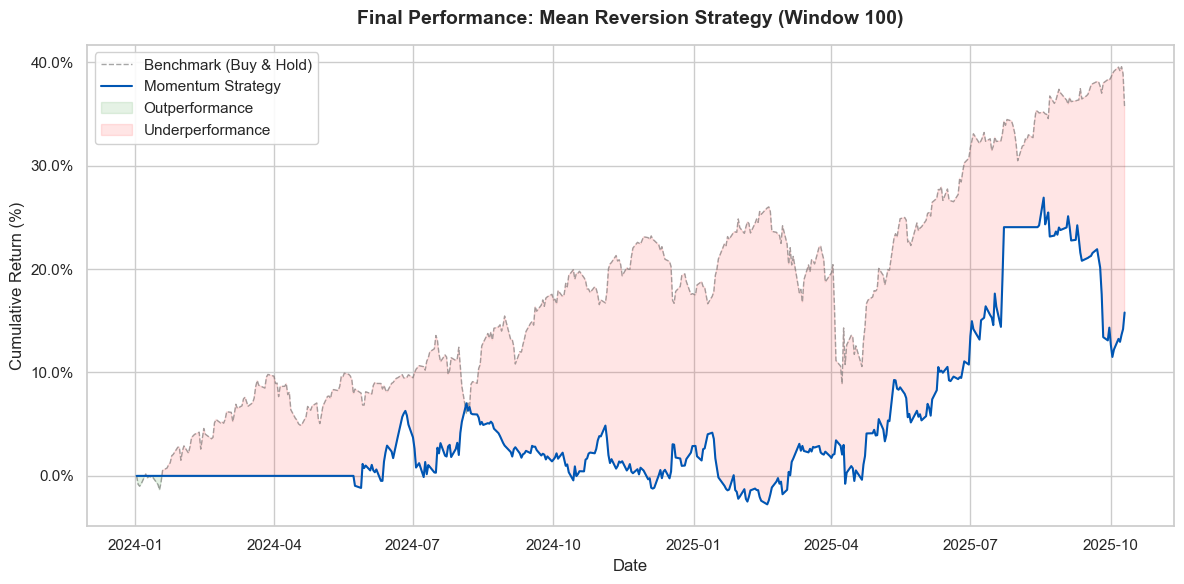

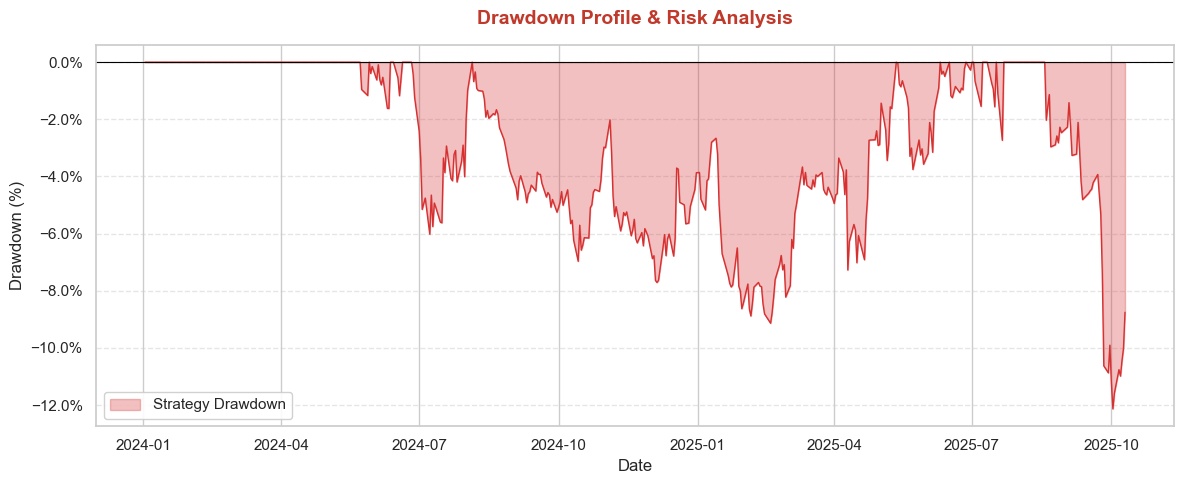

CẢNH BÁO: Phát hiện dữ liệu đầu vào là Portfolio Value ($). Đang chuyển đổi sang Returns (%)...


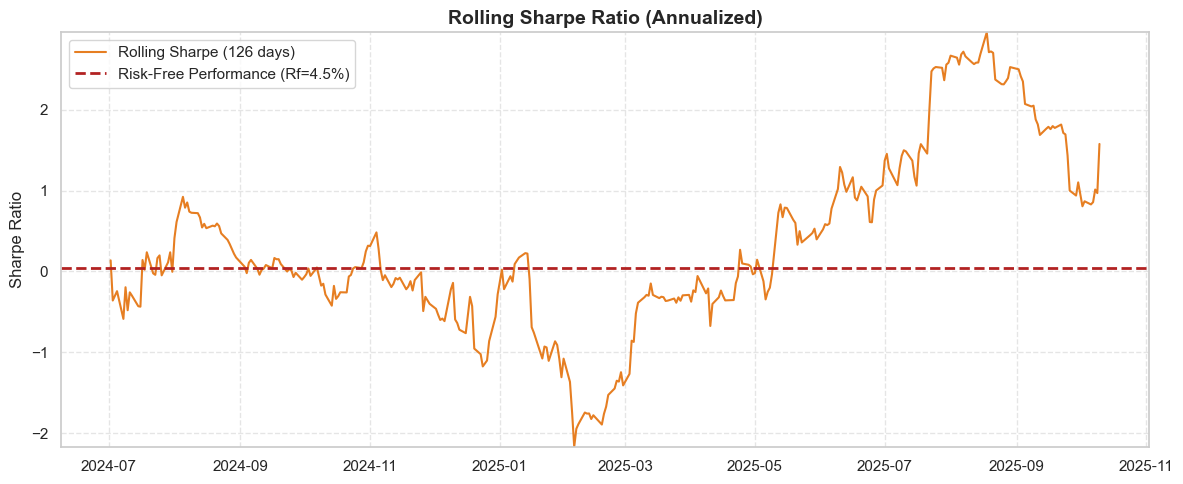

In [27]:
# Tạo Benchmark (Giả sử mua đều thị trường và nắm giữ)
# Cách tính: Trung bình Log Return của các mã -> Lũy kế
# Tạo Benchmark (Giả sử mua đều thị trường và nắm giữ)
simple_rets = np.exp(test_df['Log Return']) - 1
bench_simple_ret = simple_rets.mean(axis=1)
bench_equity = (1 + bench_simple_ret).cumprod() * tester.initial_capital

# Vẽ biểu đồ so sánh
viz.plot_strategy_vs_benchmark(
    equity_test, 
    bench_equity, 
    title=f"Final Performance: Mean Reversion Strategy (Window {best_w})"
)
# (Tuỳ chọn) Vẽ biểu đồ rủi ro (Underwater)
viz.plot_underwater(equity_test)

viz.plot_rolling_sharpe(equity_test, risk_free_rate=config.risk_free_rate)

**Nhận xét:**
- Hiệu suất (Performance): Đạt lợi nhuận xấp xỉ $+15\%$. Tuy nhiên, vẫn ở trạng thái Underperformance so với mức $+40\%$ của Benchmark.
- Rủi ro sụt giảm (Drawdown): Maximum Drawdown được kiểm soát tốt hơn ở mức $-12\%$. Chiến lược có khả năng hồi phục về High-water mark (đỉnh cũ) nhanh hơn.
- Sharpe Ratio: Chỉ số này vẫn biến động và thường xuyên rơi xuống vùng âm trong năm 2024, tuy nhiên có sự cải thiện mạnh mẽ vào cuối giai đoạn, nghĩa là bắt đầu tạo ra lợi nhuận vượt trội so với lãi suất phi rủi ro.